In [1]:
import pathlib
from pathlib import Path  # Adicione esta linha para importar a classe Path diretamente
import pandas as pd
import numpy as np
import time                # Adicionado para a Célula 5 (paralelização)
import warnings            # Adicionado para a Célula 5 (suprimir avisos)

# Suprimindo o aviso específico sobre a inferência de formato do datetime
# Comente a linha abaixo se quiser ver os avisos ou se for especificar o formato.
warnings.filterwarnings("ignore", message="Could not infer format", category=UserWarning)

RAW_DIR = Path("data/raw") # Agora Path() pode ser usado diretamente
PROC_DIR = Path("data/processed")
PROC_DIR.mkdir(exist_ok=True, parents=True)

print(f"RAW_DIR configurado para: {RAW_DIR.resolve()}")
print(f"PROC_DIR configurado para: {PROC_DIR.resolve()}")


RAW_DIR configurado para: A:\Projetos\combap25\data\raw
PROC_DIR configurado para: A:\Projetos\combap25\data\processed


In [2]:
# Célula 2: Dicionário CANON Mais Abrangente

# Mapeamos as variações de nomes de colunas (APÓS a limpeza inicial)
# para os nomes padronizados que queremos usar.
# A limpeza inicial é: .str.strip().str.lower().str.replace(r"\s+", "", regex=True)

CANON = {
    "timestamp": [
        "time(s)",                # Ex: "Time (s)" no CSV -> "time(s)"
        "time_(s)",               # Ex: "Time_(s)" no CSV -> "time_(s)"
        "time",                   # Ex: "Time" no CSV -> "time"
        "times"                   # Variação observada
    ],
    "fuel_rate": [
        "engfuelrate(l/h)",       # Ex: "EngFuelRate (L/h)" -> "engfuelrate(l/h)"
        "engfuelrate_(l/h)",      # Ex: "EngFuelRate_(L/h)" -> "engfuelrate_(l/h)"
        "engfuelrate",            # Ex: "EngFuelRate" -> "engfuelrate"
        "enginefuelrate",         # Variação
        "fuelrate",               # Variação mais curta
        "fuel_rate"               # Nome canônico também como variante
    ],
    "engine_rpm": [
        "engspeed(rpm)",          # Ex: "EngSpeed (rpm)" -> "engspeed(rpm)"
        "engspeed_(rpm)",         # Ex: "EngSpeed_(rpm)" -> "engspeed_(rpm)"
        "engspeed",               # Ex: "EngSpeed" -> "engspeed"
        "enginespeedrpm",         # Variação
        "enginespeed",            # Variação
        "engine_speed",           # Nome canônico também como variante
        "rpm"                     # Se a coluna for apenas "rpm"
    ],
    "veh_speed": [
        "speedoverground(m/s)",   # Ex: "SpeedOverGround (m/s)" -> "speedoverground(m/s)"
        "speedoverground_(m/s)",  # Ex: "SpeedOverGround_(m/s)" -> "speedoverground_(m/s)"
        "wheelbasedmachinespeed(m/s)",
        "wheelbasedmachinespeed_(m/s)",
        "groundbasedmachinespeed(m/s)",
        "groundbasedmachinespeed_(m/s)",
        "frontaxlespeed(km/h)",
        "frontaxlespeed_(km/h)",
        "wheelbasedvehiclespeed(km/h)",
        "wheelbasedvehiclespeed_(km/h)",
        "speedoverground",
        "vehiclespeed",
        "vehicle_speed",          # Nome canônico também como variante
        "veh_speed"               # Nome canônico também como variante
    ],
}

print("Dicionário CANON (v2 - mais abrangente) definido.")


Dicionário CANON (v2 - mais abrangente) definido.


In [3]:
# Célula 3 Revisada: Função tidy para Lidar com Formato de Tempo "0 days HH:MM:SS.ffffff"

# Certifique-se de que CANON está definido (Célula 2) e pd está importado (Célula 1)

def tidy(df: pd.DataFrame) -> pd.DataFrame:
    source_file_name_for_debug = df.attrs.get('source', 'desconhecido')
    # print(f"Debug Tidy - Arquivo: {source_file_name_for_debug} - Colunas Originais (início tidy): {df.columns.tolist()[:5]}")

    # 1) Padroniza nomes das colunas
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "", regex=True) # Remove todos os espaços
    )
    # print(f"Debug Tidy - Arquivo: {source_file_name_for_debug} - Colunas Após Limpeza de Nomes: {df.columns.tolist()[:5]}")

    # 2) Renomeia colunas usando o dicionário CANON
    rename_map = {}
    for canon_name, variants_in_canon in CANON.items(): # CANON deve estar definido globalmente
        for variant_from_canon in variants_in_canon: # As variantes no CANON devem estar "limpas"
            if variant_from_canon in df.columns:
                rename_map[variant_from_canon] = canon_name
                # print(f"  Debug Tidy - Mapeando '{variant_from_canon}' para '{canon_name}' em {source_file_name_for_debug}")
                break 
    df = df.rename(columns=rename_map)
    # print(f"Debug Tidy - Arquivo: {source_file_name_for_debug} - Colunas Após Renomeação CANON: {df.columns.tolist()}")

    # 3) Define as colunas esperadas e verifica se estão presentes
    expected_columns = ["timestamp", "fuel_rate", "engine_rpm", "veh_speed"]
    missing_columns = [col for col in expected_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Faltam colunas {missing_columns} em {source_file_name_for_debug} após tentativa de renomeação.")

    # 4) Converte as colunas esperadas para os tipos corretos
    for col in expected_columns:
        if col == "timestamp":
            # print(f"  Debug Tidy - Arquivo: {source_file_name_for_debug} - Processando coluna 'timestamp'")
            # print(f"    Valores originais (head) em '{col}':\n{df[col].head()}")
            try:
                # Tenta converter para timedelta e depois para segundos totais
                df[col] = pd.to_timedelta(df[col], errors='coerce').dt.total_seconds()
                # print(f"    Valores após to_timedelta().dt.total_seconds() (head):\n{df[col].head()}")
            except Exception as e_td:
                # print(f"    Falha ao converter para timedelta: {e_td}. Tentando pd.to_numeric como fallback.")
                # Fallback para pd.to_numeric se to_timedelta falhar (para arquivos que possam ter segundos como números)
                df[col] = pd.to_numeric(df[col], errors='coerce')
                # print(f"    Valores após fallback para pd.to_numeric (head):\n{df[col].head()}")
            
            # if df[col].isnull().all():
            #     print(f"    ALERTA EM TIDY: 'timestamp' tornou-se TODA NULA após processamento para o arquivo {source_file_name_for_debug}!")
        else:
            # Para as outras colunas esperadas (fuel_rate, engine_rpm, veh_speed)
            if df[col].dtype == 'object': # Se for string, tenta substituir vírgula e depois converter
                # print(f"  Debug Tidy - Arquivo: {source_file_name_for_debug} - Coluna '{col}' é objeto. Tentando substituir ',' por '.'")
                df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
            
            df[col] = pd.to_numeric(df[col], errors='coerce')
            # if df[col].isnull().all() and not df_original_column_was_all_nan: # Evita alerta se a coluna original já era toda NaN
            #     print(f"    ALERTA EM TIDY: Coluna '{col}' tornou-se TODA NULA após to_numeric para o arquivo {source_file_name_for_debug}!")
                
    # 5) Retorna apenas as colunas de interesse.
    return df[expected_columns]

print("Função tidy (Revisada para lidar com formato timedelta e depuração) definida/atualizada.")


Função tidy (Revisada para lidar com formato timedelta e depuração) definida/atualizada.


In [4]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import time # Adicione esta importação se ainda não estiver na primeira célula

def process_single_csv(csv_file_path: Path, output_dir: Path) -> str:
    """
    Lê um arquivo CSV, aplica a função tidy e salva como Parquet no output_dir,
    mantendo a estrutura de subpastas relativa ao diretório base dos CSVs.
    Retorna uma mensagem de status.
    """
    try:
        df = pd.read_csv(csv_file_path, low_memory=False, on_bad_lines="skip")
        df.attrs["source"] = csv_file_path.name
        tidy_df = tidy(df) # Usa a função tidy definida anteriormente

        # Diretório base dos CSVs para calcular o caminho relativo
        # No seu caso, os CSVs estão em PROC_DIR.
        # Se você tivesse uma estrutura como data/raw/csvs e quisesse salvar em data/processed/parquets,
        # o csv_input_root_dir seria Path("data/raw/csvs")
        csv_input_root_dir_for_relative_path = PROC_DIR 

        relative_path = csv_file_path.relative_to(csv_input_root_dir_for_relative_path)
        parquet_output_path = output_dir / relative_path.with_suffix(".parquet")

        parquet_output_path.parent.mkdir(parents=True, exist_ok=True)
        tidy_df.to_parquet(parquet_output_path, index=False)
        return f"[SUCESSO] Processado: {csv_file_path.name} -> {parquet_output_path}"
    except ValueError as ve:
        return f"[ERRO no tidy()] {csv_file_path.name}: {ve}"
    except Exception as e:
        return f"[ERRO GERAL] {csv_file_path.name}: {e}"

In [5]:
# Célula 5: Execução do Processamento Paralelo

# --- Certifique-se que as variáveis e funções das células anteriores estão definidas ---
# PROC_DIR (Path): Diretório onde os CSVs estão e onde a subpasta de Parquets será criada.
# process_single_csv (função): Função que processa um único CSV e salva como Parquet.
# ------------------------------------------------------------------------------------

if __name__ == "__main__" or "get_ipython" in locals(): # Permite rodar em script ou notebook
    
    # Diretório onde os CSVs de entrada estão localizados (e suas subpastas)
    # Conforme sua Célula 1, PROC_DIR é onde os CSVs estão.
    csv_input_root_dir = PROC_DIR 
    
    # Diretório onde os Parquets processados serão salvos
    # Criaremos uma subpasta dentro de PROC_DIR para os parquets para manter organizado
    parquet_output_root_dir = PROC_DIR / "parquets_processados" 
    parquet_output_root_dir.mkdir(exist_ok=True, parents=True)

    # Lista todos os arquivos CSV recursivamente a partir do diretório de entrada
    csv_files = list(csv_input_root_dir.rglob("*.csv"))

    if not csv_files:
        print(f"Nenhum arquivo CSV encontrado em: {csv_input_root_dir}")
    else:
        print(f"Encontrados {len(csv_files)} arquivos CSV para processar a partir de {csv_input_root_dir}.")
        
        # Define o número de threads. Ajuste conforme sua CPU.
        # Para o seu i9-12900k, 8 é um bom começo, mas pode experimentar 12 ou 16.
        num_workers = 16 
        
        start_time = time.time() # Registra o tempo de início
        
        results_log = [] # Lista para armazenar mensagens de resultado/erro
        
        with ThreadPoolExecutor(max_workers=num_workers) as executor:
            # Cria um dicionário de futuros para arquivos, para rastrear qual arquivo pertence a qual futuro
            future_to_file = {
                executor.submit(process_single_csv, csv_file, parquet_output_root_dir): csv_file 
                for csv_file in csv_files
            }
            
            print(f"Iniciando processamento com {num_workers} workers...")
            for i, future in enumerate(as_completed(future_to_file)):
                file_path = future_to_file[future]
                try:
                    result_message = future.result() # Obtém o resultado da função (mensagem de sucesso/erro)
                    results_log.append(result_message)
                    # Imprime o progresso e a mensagem de resultado
                    if (i + 1) % 10 == 0 or (i + 1) == len(csv_files): # Atualiza a cada 10 arquivos ou no último
                        print(f"Progresso: {i+1}/{len(csv_files)} - {result_message.split(':', 1)[0].strip()}")
                except Exception as exc: # Captura exceções que podem não ter sido pegas dentro da função
                    error_message = f"[ERRO CRÍTICO NO FUTURO] {file_path.name}: {exc}"
                    results_log.append(error_message)
                    if (i + 1) % 10 == 0 or (i + 1) == len(csv_files):
                        print(f"Progresso: {i+1}/{len(csv_files)} - {error_message}")
        
        end_time = time.time() # Registra o tempo de fim
        
        print(f"\nProcessamento concluído em {end_time - start_time:.2f} segundos.")
        
        # Imprime um resumo dos erros, se houver
        errors_found = [msg for msg in results_log if "[ERRO" in msg]
        if errors_found:
            print(f"\nResumo dos Erros ({len(errors_found)} arquivos com problemas de um total de {len(csv_files)}):")
            for err_msg in errors_found[:20]: # Mostra os primeiros 20 erros
                print(err_msg)
            if len(errors_found) > 20:
                print(f"... e mais {len(errors_found) - 20} erros. Verifique o log completo se salvou.")
        else:
            print(f"\nTodos os {len(csv_files)} arquivos foram processados com sucesso aparente.")

        # Opcional: Salvar log completo de resultados em um arquivo
        # log_file_path = PROC_DIR / "log_processamento_csv.txt"
        # with open(log_file_path, "w", encoding="utf-8") as f:
        #     for res_msg in results_log:
        #         f.write(res_msg + "\n")
        # print(f"Log de processamento completo salvo em {log_file_path}")


Encontrados 148 arquivos CSV para processar a partir de data\processed.
Iniciando processamento com 16 workers...
Progresso: 10/148 - [SUCESSO] Processado
Progresso: 20/148 - [SUCESSO] Processado
Progresso: 30/148 - [SUCESSO] Processado
Progresso: 40/148 - [SUCESSO] Processado
Progresso: 50/148 - [SUCESSO] Processado
Progresso: 60/148 - [SUCESSO] Processado
Progresso: 70/148 - [SUCESSO] Processado
Progresso: 80/148 - [SUCESSO] Processado
Progresso: 90/148 - [SUCESSO] Processado
Progresso: 100/148 - [SUCESSO] Processado
Progresso: 110/148 - [SUCESSO] Processado
Progresso: 120/148 - [SUCESSO] Processado
Progresso: 130/148 - [SUCESSO] Processado
Progresso: 140/148 - [SUCESSO] Processado
Progresso: 148/148 - [SUCESSO] Processado

Processamento concluído em 259.79 segundos.

Resumo dos Erros (4 arquivos com problemas de um total de 148):
[ERRO no tidy()] Field_1.csv: Faltam colunas ['veh_speed'] em Field_1.csv após tentativa de renomeação.
[ERRO no tidy()] Field_4.csv: Faltam colunas ['veh_

In [8]:
# Célula 6: Inspecionar Colunas de Arquivos com Erro

# Certifique-se de que PROC_DIR está definido (da Célula 1)
# import pathlib
# PROC_DIR = pathlib.Path("data/processed")

# Lista dos arquivos que apresentaram erro (baseado no seu output)
# Ajuste esta lista se os nomes dos arquivos ou seus caminhos completos forem diferentes.
# Precisamos encontrar o caminho completo para esses arquivos.
# Vamos assumir que eles estão em alguma subpasta de PROC_DIR.

problematic_file_names = ["Field_1.csv", "Field_4.csv", "Field_2.csv", "Field_3.csv"]
files_to_inspect = []

# Tenta encontrar os caminhos completos dos arquivos problemáticos
# Isso pode precisar de ajuste dependendo de como os "Field_X.csv" estão nomeados unicamente
# nas subpastas (ex: se há múltiplos "Field_1.csv" em diferentes subpastas de trator/atividade)
print("Procurando arquivos problemáticos para inspeção...")
for fname in problematic_file_names:
    found_files = list(PROC_DIR.rglob(f"**/{fname}")) # Procura recursivamente
    if found_files:
        # Se houver múltiplos arquivos com o mesmo nome, pegamos o primeiro para exemplo.
        # O ideal seria você especificar o caminho completo se souber qual deles falhou.
        files_to_inspect.append(found_files[0]) 
        print(f"Encontrado: {found_files[0]}")
    else:
        print(f"AVISO: Arquivo '{fname}' não encontrado recursivamente em {PROC_DIR}")

if not files_to_inspect:
    print("\nNenhum dos arquivos problemáticos especificados foi encontrado para inspeção.")
    print("Verifique os nomes e caminhos e tente novamente.")
else:
    # Vamos inspecionar o primeiro arquivo da lista como exemplo
    file_to_inspect_path = files_to_inspect[0]
    print(f"\nInspecionando colunas do arquivo: {file_to_inspect_path}")
    
    try:
        df_inspect = pd.read_csv(file_to_inspect_path, low_memory=False, on_bad_lines="skip")
        
        # Aplica a mesma limpeza de nomes de colunas que a função tidy faz inicialmente
        cleaned_columns = (
            df_inspect.columns
            .str.strip()
            .str.lower()
            .str.replace(r"\s+", "", regex=True)
        )
        
        print("\nColunas encontradas no arquivo (após limpeza inicial de nomes):")
        for col_name in cleaned_columns:
            print(col_name)
            
        # Verifica se alguma das variantes de veh_speed do CANON está presente
        print("\nVerificando variantes de 'veh_speed' do CANON:")
        veh_speed_variants_in_canon = CANON.get("veh_speed", [])
        found_speed_columns = []
        for variant in veh_speed_variants_in_canon:
            if variant in cleaned_columns:
                found_speed_columns.append(variant)
        
        if found_speed_columns:
            print(f"Variantes de 'veh_speed' encontradas no arquivo: {found_speed_columns}")
        else:
            print("Nenhuma das variantes conhecidas de 'veh_speed' (do CANON) foi encontrada neste arquivo.")
            
    except FileNotFoundError:
        print(f"ERRO: O arquivo {file_to_inspect_path} não foi encontrado. Verifique o caminho.")
    except Exception as e:
        print(f"ERRO ao tentar ler ou processar {file_to_inspect_path}: {e}")



Procurando arquivos problemáticos para inspeção...
Encontrado: data\processed\csvs\Fendt 211\Fendt 211 - Kopie\Power harrowing\Field_1.csv
Encontrado: data\processed\csvs\Fendt 314\Fendt 314 - Kopie\Fertilizing\Field_4.csv
Encontrado: data\processed\csvs\Fendt 211\Fendt 211 - Kopie\Power harrowing\Field_2.csv
Encontrado: data\processed\csvs\Fendt 314\Fendt 314 - Kopie\Disc harrowing\Field_3.csv

Inspecionando colunas do arquivo: data\processed\csvs\Fendt 211\Fendt 211 - Kopie\Power harrowing\Field_1.csv

Colunas encontradas no arquivo (após limpeza inicial de nomes):
index_[-]
engspeed_(rpm)
actualengpercenttorque_(%)
driversdemandengpercenttorque_(%)
engfuelrate_(l/h)
engreferencetorque_[nm]
altitude_(m)
longitude_(°)
latitude_(°)
engpercentloadatcurrentspeed_(%)
accelpedalpos1_(%)
engcoolantpress_(kpa)
engoilpress_(kpa)
engfueldeliverypress_(kpa)
engcoolanttemp_(°c)
engintakemanifold1temp_(°c)
engintakemanifold1press_(kpa)
frontaxlespeed_(km/h)
speedoverground_(m/s)
courseoverground_

In [13]:
# Célula 7: Depuração Focada em um Arquivo Específico com Erro de 'veh_speed'

# Certifique-se de que as Células 1 (imports, PROC_DIR) e 2 (CANON atualizado) foram executadas recentemente.
# from pathlib import Path # Deve estar na Célula 1
# import pandas as pd      # Deve estar na Célula 1
# CANON                    # Deve estar definido pela Célula 2

# 1. Cole o caminho completo de UM dos arquivos que FALHOU na Célula 5 com erro de 'veh_speed'
#    Copie diretamente do log de erro da Célula 5.
#    Exemplo: r"data\processed\csvs\Fendt 211\Fendt 211 - Kopie\Power harrowing\Field_1.csv"
path_arquivo_problematico_str = r"data\processed\csvs\Fendt 314\Fendt 314 - Kopie\Disc harrowing\Field_3.csv" # <--- SUBSTITUA ESTA LINHA

print(f"--- Depurando o arquivo: {path_arquivo_problematico_str} ---")

try:
    path_arquivo_problematico = Path(path_arquivo_problematico_str)
    if not path_arquivo_problematico.exists():
        print(f"ERRO DE DEPURAÇÃO: Arquivo não encontrado em: {path_arquivo_problematico}")
        print("Verifique se o caminho foi copiado corretamente.")
    else:
        df_debug = pd.read_csv(path_arquivo_problematico, low_memory=False, on_bad_lines="skip")
        print(f"\n1. Colunas originais (primeiras 5): {df_debug.columns.tolist()[:5]}")

        # 2. Aplica a MESMA limpeza de nomes de colunas que a função tidy() faz
        colunas_limpas_debug = (
            df_debug.columns
            .str.strip()
            .str.lower()
            .str.replace(r"\s+", "", regex=True)
        )
        df_debug.columns = colunas_limpas_debug
        print(f"\n2. Colunas após limpeza (primeiras 5): {df_debug.columns.tolist()[:5]}")
        # print("\nTodas as colunas limpas:")
        # for col_name in df_debug.columns:
        #     print(col_name)

        # 3. Verifica manualmente as variantes de 'veh_speed' do CANON
        variantes_veh_speed_canon = CANON.get("veh_speed", [])
        colunas_velocidade_encontradas_debug = []
        
        print(f"\n3. Procurando por variantes de 'veh_speed' no CANON (total de {len(variantes_veh_speed_canon)} variantes):")
        for variante_canon in variantes_veh_speed_canon:
            if variante_canon in df_debug.columns: # df_debug.columns agora estão limpas
                colunas_velocidade_encontradas_debug.append(variante_canon)
                print(f"  ENCONTRADO: Variante do CANON '{variante_canon}' está presente no arquivo como '{variante_canon}'.")
        
        if colunas_velocidade_encontradas_debug:
            print(f"\n   ---> SUCESSO NA DEPURAÇÃO: Variantes de 'veh_speed' encontradas neste arquivo: {colunas_velocidade_encontradas_debug}")
            # Se chegou aqui, a renomeação deveria funcionar.
            # Vamos tentar renomear para 'veh_speed'
            rename_map_debug = {}
            for col_achada in colunas_velocidade_encontradas_debug:
                rename_map_debug[col_achada] = "veh_speed" # Mapeia todas encontradas (embora tidy só pegue a primeira)
            
            df_renomeado_debug = df_debug.rename(columns=rename_map_debug)
            if "veh_speed" in df_renomeado_debug.columns:
                print("      ---> A coluna foi CORRETAMENTE RENOMEADA para 'veh_speed' nesta depuração.")
            else:
                print("      ---> ERRO DE LÓGICA: Embora variantes tenham sido encontradas, a renomeação para 'veh_speed' falhou.")
        else:
            print(f"\n   ---> FALHA NA DEPURAÇÃO: NENHUMA das {len(variantes_veh_speed_canon)} variantes de 'veh_speed' do CANON foi encontrada nas colunas limpas deste arquivo.")
            print("      Isso confirma que a coluna de velocidade está ausente ou tem um nome completamente diferente e não coberto pelo CANON.")

except FileNotFoundError:
    print(f"ERRO DE DEPURAÇÃO: O arquivo especificado para depuração não foi encontrado: {path_arquivo_problematico_str}")
except NameError as ne:
    if 'CANON' in str(ne):
        print("ERRO DE DEPURAÇÃO: O dicionário 'CANON' não está definido. Execute a Célula 2.")
    elif 'Path' in str(ne) or 'pd' in str(ne):
        print("ERRO DE DEPURAÇÃO: 'Path' ou 'pd' não está definido. Execute a Célula 1.")
    else:
        print(f"ERRO DE DEPURAÇÃO (NameError): {ne}")
except Exception as e:
    print(f"ERRO INESPERADO DURANTE A DEPURAÇÃO do arquivo {path_arquivo_problematico_str}: {e}")



--- Depurando o arquivo: data\processed\csvs\Fendt 314\Fendt 314 - Kopie\Disc harrowing\Field_3.csv ---

1. Colunas originais (primeiras 5): ['index_[-]', 'EngSpeed_(RPM)', 'ActualEngPercentTorque_(%)', 'DriversDemandEngPercentTorque_(%)', 'EngFuelRate_(L/h)']

2. Colunas após limpeza (primeiras 5): ['index_[-]', 'engspeed_(rpm)', 'actualengpercenttorque_(%)', 'driversdemandengpercenttorque_(%)', 'engfuelrate_(l/h)']

3. Procurando por variantes de 'veh_speed' no CANON (total de 14 variantes):
  ENCONTRADO: Variante do CANON 'speedoverground_(m/s)' está presente no arquivo como 'speedoverground_(m/s)'.
  ENCONTRADO: Variante do CANON 'wheelbasedmachinespeed_(m/s)' está presente no arquivo como 'wheelbasedmachinespeed_(m/s)'.
  ENCONTRADO: Variante do CANON 'groundbasedmachinespeed_(m/s)' está presente no arquivo como 'groundbasedmachinespeed_(m/s)'.
  ENCONTRADO: Variante do CANON 'frontaxlespeed_(km/h)' está presente no arquivo como 'frontaxlespeed_(km/h)'.
  ENCONTRADO: Variante do C

In [6]:
# Célula 8: Processar Sequencialmente os 4 Arquivos CSV Restantes

# Certifique-se de que as Células 1, 2, 3 e 4 foram executadas para definir:
# PROC_DIR, CANON, tidy, process_single_csv (embora vamos chamar tidy diretamente aqui)
# from pathlib import Path # Da Célula 1
# import pandas as pd      # Da Célula 1

print("--- Iniciando processamento sequencial dos arquivos restantes ---")

# Cole aqui os caminhos COMPLETOS dos 4 arquivos que falharam na Célula 5
# Obtenha-os do log de erro da Célula 5 (que agora inclui o caminho completo graças à Célula 4 atualizada)
# Use raw strings (r"...") para caminhos no Windows.
caminhos_arquivos_restantes_str = [
    r"data\processed\csvs\Fendt 211\Fendt 211 - Kopie\Power harrowing\Field_1.csv", # Exemplo, substitua pelos seus
    r"data\processed\csvs\Fendt 314\Fendt 314 - Kopie\Fertilizing\Field_4.csv",   # Exemplo, substitua pelos seus
    r"data\processed\csvs\Fendt 211\Fendt 211 - Kopie\Power harrowing\Field_2.csv", # Exemplo, substitua pelos seus
    r"data\processed\csvs\Fendt 314\Fendt 314 - Kopie\Disc harrowing\Field_3.csv"    # Exemplo, substitua pelos seus
]

# Diretório onde os Parquets processados devem ser salvos
# O mesmo usado na Célula 5
parquet_output_root_dir = PROC_DIR / "parquets_processados" 
parquet_output_root_dir.mkdir(exist_ok=True, parents=True)

arquivos_processados_sequencialmente = 0
erros_sequenciais = []

for path_str in caminhos_arquivos_restantes_str:
    csv_file_path = Path(path_str)
    print(f"\nProcessando: {csv_file_path}...")
    if not csv_file_path.exists():
        msg = f"[ERRO SEQUENCIAL] Arquivo não encontrado: {csv_file_path}"
        print(msg)
        erros_sequenciais.append(msg)
        continue
    
    try:
        # Reutilizando a lógica da função process_single_csv, mas executando diretamente
        df = pd.read_csv(csv_file_path, low_memory=False, on_bad_lines="skip")
        df.attrs["source"] = csv_file_path.name
        
        tidy_df = tidy(df) # Usa a função tidy definida na Célula 3 (com o CANON da Célula 2)

        csv_input_root_dir_for_relative_path = PROC_DIR # Conforme Célula 4
        relative_path = csv_file_path.relative_to(csv_input_root_dir_for_relative_path)
        parquet_output_path = parquet_output_root_dir / relative_path.with_suffix(".parquet")
        
        parquet_output_path.parent.mkdir(parents=True, exist_ok=True)
        tidy_df.to_parquet(parquet_output_path, index=False)
        
        print(f"[SUCESSO SEQUENCIAL] Processado: {csv_file_path.name} -> {parquet_output_path}")
        arquivos_processados_sequencialmente += 1
    except ValueError as ve:
        msg = f"[ERRO SEQUENCIAL no tidy()] {csv_file_path.name}: {ve}"
        print(msg)
        erros_sequenciais.append(msg)
    except Exception as e:
        msg = f"[ERRO GERAL SEQUENCIAL] {csv_file_path.name}: {e}"
        print(msg)
        erros_sequenciais.append(msg)

print(f"\n--- Processamento sequencial concluído ---")
print(f"Arquivos processados com sucesso nesta etapa: {arquivos_processados_sequencialmente}")
if erros_sequenciais:
    print("Erros encontrados nesta etapa:")
    for err in erros_sequenciais:
        print(err)
else:
    if arquivos_processados_sequencialmente == len(caminhos_arquivos_restantes_str):
        print("Todos os arquivos restantes foram processados com sucesso sequencialmente!")



--- Iniciando processamento sequencial dos arquivos restantes ---

Processando: data\processed\csvs\Fendt 211\Fendt 211 - Kopie\Power harrowing\Field_1.csv...
[SUCESSO SEQUENCIAL] Processado: Field_1.csv -> data\processed\parquets_processados\csvs\Fendt 211\Fendt 211 - Kopie\Power harrowing\Field_1.parquet

Processando: data\processed\csvs\Fendt 314\Fendt 314 - Kopie\Fertilizing\Field_4.csv...
[SUCESSO SEQUENCIAL] Processado: Field_4.csv -> data\processed\parquets_processados\csvs\Fendt 314\Fendt 314 - Kopie\Fertilizing\Field_4.parquet

Processando: data\processed\csvs\Fendt 211\Fendt 211 - Kopie\Power harrowing\Field_2.csv...
[SUCESSO SEQUENCIAL] Processado: Field_2.csv -> data\processed\parquets_processados\csvs\Fendt 211\Fendt 211 - Kopie\Power harrowing\Field_2.parquet

Processando: data\processed\csvs\Fendt 314\Fendt 314 - Kopie\Disc harrowing\Field_3.csv...
[SUCESSO SEQUENCIAL] Processado: Field_3.csv -> data\processed\parquets_processados\csvs\Fendt 314\Fendt 314 - Kopie\Disc ha

In [10]:
# Célula 9 Final: Excluir Arquivos Problemáticos, Consolidar, Enriquecer e Depurar Timestamp
# Versão que salva como "telemetry_full.parquet"

# Certifique-se de que as Células 1 (imports, PROC_DIR) foi executada.
# from pathlib import Path # Da Célula 1
# import pandas as pd      # Da Célula 1
# PROC_DIR                 # Definido na Célula 1

print("--- Iniciando Célula 9 (Final): Excluir Arquivos, Consolidar, Enriquecer e Depurar ---")

parquet_input_root_dir = PROC_DIR / "parquets_processados"
curated_data_dir = PROC_DIR.parent / "curated"
curated_data_dir.mkdir(exist_ok=True, parents=True)

# Lista dos caminhos COMPLETOS dos 4 arquivos a serem EXCLUÍDOS
# Estes são os caminhos relativos à raiz do seu projeto.
# Certifique-se que estes caminhos correspondem exatamente aos arquivos que falharam.
# Usamos strings brutas (r"...") para caminhos no Windows.
# Estes caminhos são para os arquivos PARQUET na pasta 'parquets_processados'.
caminhos_para_excluir_str = [
    r"data/processed/parquets_processados/csvs/Fendt 211/Fendt 211 - Kopie/Power harrowing/Field_1.parquet",
    r"data/processed/parquets_processados/csvs/Fendt 314/Fendt 314 - Kopie/Fertilizing/Field_4.parquet",
    r"data/processed/parquets_processados/csvs/Fendt 211/Fendt 211 - Kopie/Power harrowing/Field_2.parquet",
    r"data/processed/parquets_processados/csvs/Fendt 314/Fendt 314 - Kopie/Disc harrowing/Field_3.parquet"
]
# Converte para objetos Path e normaliza para comparação (resolve para caminhos absolutos)
arquivos_a_excluir_normalizados = {str(Path(p).resolve()) for p in caminhos_para_excluir_str}


if not parquet_input_root_dir.exists():
    print(f"ERRO: Diretório de entrada dos Parquets não encontrado: {parquet_input_root_dir}")
else:
    all_parquet_files_raw = list(parquet_input_root_dir.rglob("*.parquet"))
    
    all_parquet_files = []
    excluded_count = 0
    for pf_path in all_parquet_files_raw:
        if str(pf_path.resolve()) not in arquivos_a_excluir_normalizados:
            all_parquet_files.append(pf_path)
        else:
            print(f"EXCLUINDO da consolidação: {pf_path.relative_to(parquet_input_root_dir.parent.parent)}") # Mostra caminho relativo à raiz do projeto
            excluded_count +=1

    if not all_parquet_files:
        print(f"Nenhum arquivo Parquet restante para consolidar em: {parquet_input_root_dir} após excluir {excluded_count} arquivos.")
    else:
        print(f"Encontrados {len(all_parquet_files)} arquivos Parquet para consolidar (após excluir {excluded_count} arquivos).")
        
        list_of_dataframes = []
        problemas_na_leitura = 0

        for i, parquet_file_path in enumerate(all_parquet_files):
            try:
                if (i + 1) % 20 == 0 or (i + 1) == len(all_parquet_files) or i == 0: 
                    print(f"Lendo e enriquecendo arquivo {i+1}/{len(all_parquet_files)}: {parquet_file_path.relative_to(parquet_input_root_dir)}")

                df_single = pd.read_parquet(parquet_file_path)
                
                if 'timestamp' not in df_single.columns:
                    print(f"  AVISO: Coluna 'timestamp' AUSENTE em {parquet_file_path.name} ao ler o Parquet.")
                    df_single['timestamp'] = pd.NA 
                elif df_single['timestamp'].isnull().all():
                    print(f"  AVISO: Coluna 'timestamp' está TODA NULA em {parquet_file_path.name} ao ler o Parquet.")
                elif not pd.api.types.is_numeric_dtype(df_single['timestamp']):
                    print(f"  AVISO: Coluna 'timestamp' NÃO É NUMÉRICA ({df_single['timestamp'].dtype}) em {parquet_file_path.name}. Tentando converter...")
                    df_single['timestamp'] = pd.to_numeric(df_single['timestamp'], errors='coerce')
                    if df_single['timestamp'].isnull().all():
                         print(f"    CONVERSÃO FALHOU: 'timestamp' ainda toda nula após to_numeric em {parquet_file_path.name}.")

                df_single['source_file'] = parquet_file_path.stem 

                path_parts = list(parquet_file_path.relative_to(parquet_input_root_dir).parts)
                
                if path_parts and path_parts[0].lower() == "csvs": 
                    relevant_parts = path_parts[1:]
                else:
                    relevant_parts = path_parts
                
                tractor_name = "Desconhecido"
                activity_name = "Geral"

                if len(relevant_parts) >= 2:
                    tractor_name = relevant_parts[0]
                    part1_lower = relevant_parts[1].lower()
                    if part1_lower.endswith(".parquet"):
                        pass
                    elif "kopie" in part1_lower: 
                        if len(relevant_parts) >= 4 and not relevant_parts[2].lower().endswith(".parquet"):
                            activity_name = relevant_parts[2]
                    else:
                        activity_name = relevant_parts[1]
                elif len(relevant_parts) == 1 and relevant_parts[0].lower().endswith(".parquet"):
                    tractor_name = "Raiz_Desconhecida"
                    activity_name = "Raiz_Desconhecida"
                else:
                    print(f"AVISO DE ESTRUTURA: Não foi possível extrair trator/atividade para {parquet_file_path}. Partes: {relevant_parts}")

                df_single['tractor'] = tractor_name
                df_single['activity'] = activity_name
                
                list_of_dataframes.append(df_single)

            except Exception as e:
                print(f"ERRO CRÍTICO ao processar o arquivo Parquet {parquet_file_path}: {e}")
                problemas_na_leitura += 1

        if problemas_na_leitura > 0:
            print(f"\nAVISO: {problemas_na_leitura} arquivos Parquet tiveram problemas críticos durante a leitura/enriquecimento.")

        if list_of_dataframes:
            print("\nConcatenando todos os DataFrames...")
            try:
                full_df = pd.concat(list_of_dataframes, ignore_index=True)
            except Exception as e:
                print(f"ERRO DURANTE A CONCATENAÇÃO: {e}")
                full_df = pd.DataFrame() 
            
            if not full_df.empty:
                print(f"\nShape do DataFrame consolidado: {full_df.shape}")
                print(f"Colunas no DataFrame consolidado: {full_df.columns.tolist()}")

                if 'timestamp' in full_df.columns:
                    print("\nInformações da coluna 'timestamp' no DataFrame CONSOLIDADO (ANTES DE SALVAR):")
                    full_df['timestamp'].info() 
                    print(f"Valores nulos (NaN) em 'timestamp' (consolidado): {full_df['timestamp'].isnull().sum()} de {len(full_df)}")
                    if full_df['timestamp'].isnull().all():
                        print("ALERTA CRÍTICO: 'timestamp' está TODA NULA no DataFrame consolidado ANTES DE SALVAR!")
                    else:
                        print("Descrição de 'timestamp' (consolidado, ANTES DE SALVAR):")
                        print(full_df['timestamp'].describe())
                else:
                    print("ALERTA CRÍTICO: Coluna 'timestamp' AUSENTE no DataFrame consolidado ANTES DE SALVAR!")

                if 'source_file' not in full_df.columns:
                     print("ALERTA CRÍTICO: Coluna 'source_file' AUSENTE no DataFrame consolidado ANTES DE SALVAR!")

                # Alterado para o nome original do arquivo
                output_file_consolidado = curated_data_dir / "telemetry_full.parquet" 
                print(f"\nSalvando DataFrame consolidado em: {output_file_consolidado}...")
                full_df.to_parquet(output_file_consolidado, index=False, engine='pyarrow', compression='snappy')
                print(f"DataFrame consolidado e enriquecido salvo.")

                # VERIFICAÇÃO PÓS-SALVAMENTO: Carrega o arquivo que acabou de ser salvo e verifica 'timestamp'
                print(f"\nVERIFICANDO o arquivo salvo: {output_file_consolidado}")
                df_reloaded_check = pd.read_parquet(output_file_consolidado)
                print(f"Shape do DataFrame RECARREGADO: {df_reloaded_check.shape}")
                print(f"Colunas no DataFrame RECARREGADO: {df_reloaded_check.columns.tolist()}")
                if 'timestamp' in df_reloaded_check.columns:
                    print("Informações da coluna 'timestamp' no DataFrame RECARREGADO:")
                    df_reloaded_check['timestamp'].info()
                    print(f"Valores nulos (NaN) em 'timestamp' (RECARREGADO): {df_reloaded_check['timestamp'].isnull().sum()} de {len(df_reloaded_check)}")
                    if df_reloaded_check['timestamp'].isnull().all():
                        print("PROBLEMA PERSISTE: 'timestamp' AINDA está TODA NULA no DataFrame RECARREGADO!")
                    else:
                        print("BOA NOTÍCIA: 'timestamp' parece OK no DataFrame RECARREGADO.")
                        print(df_reloaded_check['timestamp'].describe())
                else:
                    print("PROBLEMA GRAVE: 'timestamp' NÃO FOI SALVA ou lida corretamente do Parquet.")
                
                if 'source_file' not in df_reloaded_check.columns:
                     print("PROBLEMA GRAVE: 'source_file' NÃO FOI SALVA ou lida corretamente do Parquet.")

            else:
                print("DataFrame consolidado está vazio após tentativa de concatenação.")
        else:
            print("Nenhum DataFrame foi carregado para consolidação (possivelmente devido a erros na leitura dos Parquets ou todos foram excluídos).")

print("\n--- Célula 9 (Final) concluída ---")


--- Iniciando Célula 9 (Final): Excluir Arquivos, Consolidar, Enriquecer e Depurar ---
EXCLUINDO da consolidação: processed\parquets_processados\csvs\Fendt 211\Fendt 211 - Kopie\Power harrowing\Field_1.parquet
EXCLUINDO da consolidação: processed\parquets_processados\csvs\Fendt 211\Fendt 211 - Kopie\Power harrowing\Field_2.parquet
EXCLUINDO da consolidação: processed\parquets_processados\csvs\Fendt 314\Fendt 314 - Kopie\Disc harrowing\Field_3.parquet
EXCLUINDO da consolidação: processed\parquets_processados\csvs\Fendt 314\Fendt 314 - Kopie\Fertilizing\Field_4.parquet
Encontrados 140 arquivos Parquet para consolidar (após excluir 4 arquivos).
Lendo e enriquecendo arquivo 1/140: csvs\Fendt 211\Fendt 211 - Kopie\Fendt 211.parquet
Lendo e enriquecendo arquivo 20/140: csvs\Fendt 314\Fendt 314 - Kopie\Mowing (front)\Field_1.parquet
Lendo e enriquecendo arquivo 40/140: csvs\Fendt 314\Fendt 314 - Kopie\Spraying\Field_10.parquet
  AVISO: Coluna 'timestamp' está TODA NULA em Field_1.parquet ao l

In [11]:
# Célula 10 Revisada: Depuração e Cálculo Correto do Consumo de Diesel e Estatísticas

# Certifique-se de que a Célula 1 (imports, PROC_DIR) e a Célula 9 (criação de telemetry_full.parquet) foram executadas.
# from pathlib import Path # Da Célula 1
# import pandas as pd      # Da Célula 1
# curated_data_dir         # Definido na Célula 9

print("--- Iniciando Célula 10 (Revisada): Depuração e Cálculo de Consumo ---")

# Carrega o DataFrame consolidado
consolidated_parquet_path = curated_data_dir / "telemetry_full.parquet"
if not consolidated_parquet_path.exists():
    print(f"ERRO: Arquivo consolidado não encontrado: {consolidated_parquet_path}")
    print("Execute a Célula 9 primeiro.")
    # Se o arquivo não existe, não podemos continuar, então saímos ou levantamos um erro
    # raise FileNotFoundError(f"Arquivo consolidado não encontrado: {consolidated_parquet_path}") 
else:
    print(f"Carregando DataFrame consolidado de: {consolidated_parquet_path}")
    full_df = pd.read_parquet(consolidated_parquet_path)
    print(f"Shape do DataFrame carregado: {full_df.shape}")
    print(f"Colunas disponíveis: {full_df.columns.tolist()}")

    # --- ETAPA DE DEPURAÇÃO DA COLUNA 'timestamp' ---
    if 'timestamp' not in full_df.columns:
        print("ERRO CRÍTICO: A coluna 'timestamp' não existe no DataFrame consolidado.")
        # raise KeyError("A coluna 'timestamp' é essencial e não foi encontrada.")
    else:
        print("\n--- Depurando a coluna 'timestamp' ---")
        print("Informações da coluna 'timestamp':")
        full_df['timestamp'].info()
        print("\nPrimeiras 5 linhas da coluna 'timestamp':")
        print(full_df['timestamp'].head())
        print(f"\nValores nulos (NaN) em 'timestamp': {full_df['timestamp'].isnull().sum()} de {len(full_df)}")
        
        # Tenta converter para numérico (float) se ainda não for, tratando possíveis strings problemáticas
        # Isso é uma segurança adicional caso a conversão na função tidy() não tenha sido suficiente
        # para todos os casos ou se o Parquet foi salvo de forma inesperada.
        if not pd.api.types.is_numeric_dtype(full_df['timestamp']):
            print("Coluna 'timestamp' não é numérica. Tentando converter para float...")
            # Tenta substituir vírgulas por pontos (comum em formatos decimais europeus) e depois converter
            if full_df['timestamp'].dtype == 'object':
                 try:
                    full_df['timestamp'] = full_df['timestamp'].str.replace(',', '.', regex=False).astype(float)
                 except AttributeError: # Se não for string, mas ainda objeto, pd.to_numeric é melhor
                    full_df['timestamp'] = pd.to_numeric(full_df['timestamp'], errors='coerce')
                 except Exception as e:
                    print(f"Erro ao tentar converter 'timestamp' (com str.replace): {e}")
                    full_df['timestamp'] = pd.to_numeric(full_df['timestamp'], errors='coerce')
            else:
                 full_df['timestamp'] = pd.to_numeric(full_df['timestamp'], errors='coerce')
            
            print("Informações da coluna 'timestamp' APÓS tentativa de conversão para numérico:")
            full_df['timestamp'].info()
            print("\nPrimeiras 5 linhas da coluna 'timestamp' APÓS conversão:")
            print(full_df['timestamp'].head())
            print(f"\nValores nulos (NaN) em 'timestamp' APÓS conversão: {full_df['timestamp'].isnull().sum()}")

        # Verifica se ainda há muitos NaNs, o que indicaria problema na origem dos dados
        if full_df['timestamp'].isnull().sum() > len(full_df) * 0.5: # Se mais de 50% for NaN
            print("AVISO: Mais de 50% dos valores de 'timestamp' são NaN após a conversão. Verifique os dados de origem.")
        
        print(full_df[['timestamp', 'fuel_rate', 'engine_rpm', 'veh_speed']].describe())
        # --- FIM DA ETAPA DE DEPURAÇÃO ---

        # Colunas para agrupar ao calcular o diff de tempo. 'source_file' é crucial.
        if 'source_file' not in full_df.columns:
            print("ERRO CRÍTICO: Coluna 'source_file' não encontrada. O cálculo de delta_t será impreciso.")
            print("Certifique-se de que 'source_file' foi adicionada na Célula 9.")
            # raise KeyError("A coluna 'source_file' é essencial e não foi encontrada.")
            grouping_cols_for_time_diff = ['tractor', 'activity'] # Fallback menos preciso
        else:
            grouping_cols_for_time_diff = ['tractor', 'activity', 'source_file']

        print(f"\nOrdenando dados por {grouping_cols_for_time_diff} e 'timestamp' para cálculo de delta_t...")
        full_df = full_df.sort_values(by=grouping_cols_for_time_diff + ['timestamp'])

        # Calcula a diferença de tempo (em segundos) entre leituras consecutivas DENTRO de cada grupo
        print("Calculando 'delta_t_seconds'...")
        full_df['delta_t_seconds'] = full_df.groupby(grouping_cols_for_time_diff, observed=True)['timestamp'].diff()

        # Preenche o primeiro NaN de cada grupo.
        # Se a primeira leitura de timestamp for 0.000, seu delta pode ser 0.
        # Se a amostragem for, por exemplo, a cada 0.010s, o primeiro delta poderia ser 0.010.
        # Por segurança, e para evitar superestimar o primeiro consumo, preencher com 0 é uma opção.
        # Outra opção é usar bfill para preencher com o próximo delta válido (se houver mais de 1 registro no grupo)
        # ou com uma taxa de amostragem média/mediana se conhecida.
        # Vamos preencher com 0 por enquanto, mas isso pode ser refinado.
        full_df['delta_t_seconds'] = full_df['delta_t_seconds'].fillna(0)
        
        # Remove deltas negativos ou excessivamente grandes (ex: > 10 minutos entre leituras da mesma sessão)
        # Isso pode indicar saltos nos dados ou problemas na concatenação/ordenação.
        max_reasonable_delta_t_seconds = 600 # 10 minutos
        full_df.loc[full_df['delta_t_seconds'] < 0, 'delta_t_seconds'] = 0
        full_df.loc[full_df['delta_t_seconds'] > max_reasonable_delta_t_seconds, 'delta_t_seconds'] = 0 # Ou um valor de cap

        full_df['delta_t_hours'] = full_df['delta_t_seconds'] / 3600.0
        full_df['liters_consumed'] = full_df['fuel_rate'] * full_df['delta_t_hours']
        full_df['liters_consumed'] = full_df['liters_consumed'].fillna(0) # Garante que não haja NaN

        print("\nColunas 'delta_t_seconds', 'delta_t_hours', 'liters_consumed' adicionadas e tratadas.")
        print("Amostra das colunas de tempo e consumo:")
        print(full_df[['timestamp', 'delta_t_seconds', 'fuel_rate', 'delta_t_hours', 'liters_consumed']].head(10))
        print("\nDescrição das colunas de tempo e consumo:")
        print(full_df[['delta_t_seconds', 'delta_t_hours', 'liters_consumed']].describe())
        
        # Filtra linhas onde 'total_hours_operational' seria zero ou negativo para evitar divisão por zero
        # Isso pode acontecer se houver apenas um registro para um grupo ou se os timestamps forem problemáticos.
        # A agregação de 'delta_t_seconds' já deve dar a duração correta.

        print("\nCalculando estatísticas agregadas por trator e atividade...")
        stats_df = full_df.groupby(['tractor', 'activity'], observed=True).agg(
            total_duration_seconds=pd.NamedAgg(column='delta_t_seconds', aggfunc='sum'),
            total_liters_consumed=pd.NamedAgg(column='liters_consumed', aggfunc='sum'),
            avg_engine_rpm=pd.NamedAgg(column='engine_rpm', aggfunc='mean'), # Média ponderada pelo tempo seria melhor
            avg_veh_speed_m_s=pd.NamedAgg(column='veh_speed', aggfunc='mean'), # Média ponderada pelo tempo seria melhor
            count_records=pd.NamedAgg(column='timestamp', aggfunc='count')
        ).reset_index()

        stats_df['total_hours_operational'] = stats_df['total_duration_seconds'] / 3600.0
        
        stats_df['avg_fuel_consumption_l_h'] = stats_df.apply(
            lambda row: row['total_liters_consumed'] / row['total_hours_operational'] 
            if row['total_hours_operational'] > 1e-6 else 0, # Evita divisão por zero ou por valores muito pequenos
            axis=1
        )
        # Remove colunas intermediárias se não forem mais necessárias
        # stats_df = stats_df.drop(columns=['total_duration_seconds'])


        print("\nEstatísticas Agregadas (stats_df):")
        print(stats_df.head())
        print(f"\nShape de stats_df: {stats_df.shape}")
        print("\nDescrição de colunas chave em stats_df:")
        print(stats_df[['total_hours_operational', 'total_liters_consumed', 'avg_fuel_consumption_l_h']].describe().T)


        stats_output_file = curated_data_dir / "telemetry_stats.parquet" # Salva com novo nome para não sobrescrever
        stats_df.to_parquet(stats_output_file, index=False)
        print(f"\nEstatísticas agregadas salvas em: {stats_output_file}")

print("\n--- Célula 10 (Revisada) concluída ---")


--- Iniciando Célula 10 (Revisada): Depuração e Cálculo de Consumo ---
Carregando DataFrame consolidado de: data\curated\telemetry_full.parquet
Shape do DataFrame carregado: (42961792, 7)
Colunas disponíveis: ['timestamp', 'fuel_rate', 'engine_rpm', 'veh_speed', 'source_file', 'tractor', 'activity']

--- Depurando a coluna 'timestamp' ---
Informações da coluna 'timestamp':
<class 'pandas.core.series.Series'>
RangeIndex: 42961792 entries, 0 to 42961791
Series name: timestamp
Non-Null Count     Dtype  
--------------     -----  
41910513 non-null  float64
dtypes: float64(1)
memory usage: 327.8 MB

Primeiras 5 linhas da coluna 'timestamp':
0    0.0
1    0.1
2    0.2
3    0.3
4    0.4
Name: timestamp, dtype: float64

Valores nulos (NaN) em 'timestamp': 1051279 de 42961792
          timestamp     fuel_rate    engine_rpm     veh_speed
count  4.191051e+07  4.296179e+07  4.296179e+07  4.296179e+07
mean   6.347214e+06  1.504388e+01  1.255276e+03  2.476313e+00
std    6.917510e+06  1.340355e+01  

--- Iniciando Célula 11 (Corrigida): Análise de Sanidade e Visualizações ---
Carregando estatísticas de: data\curated\telemetry_stats.parquet

Verificando dados nulos em stats_df:
tractor                     0
activity                    0
total_duration_seconds      0
total_liters_consumed       0
avg_engine_rpm              0
avg_veh_speed_m_s           0
count_records               0
total_hours_operational     0
avg_fuel_consumption_l_h    0
dtype: int64

Estatísticas descritivas básicas de stats_df:
                          count         mean          std          min  \
total_hours_operational    33.0    41.303463    81.750569     0.000000   
total_liters_consumed      33.0   596.148594  1097.686621     0.000000   
avg_engine_rpm             33.0  1450.758702   185.142234  1027.910254   
avg_veh_speed_m_s          33.0     2.294481     0.765390     0.891265   
avg_fuel_consumption_l_h   33.0    15.501490     8.300301     0.000000   

                                  25%        

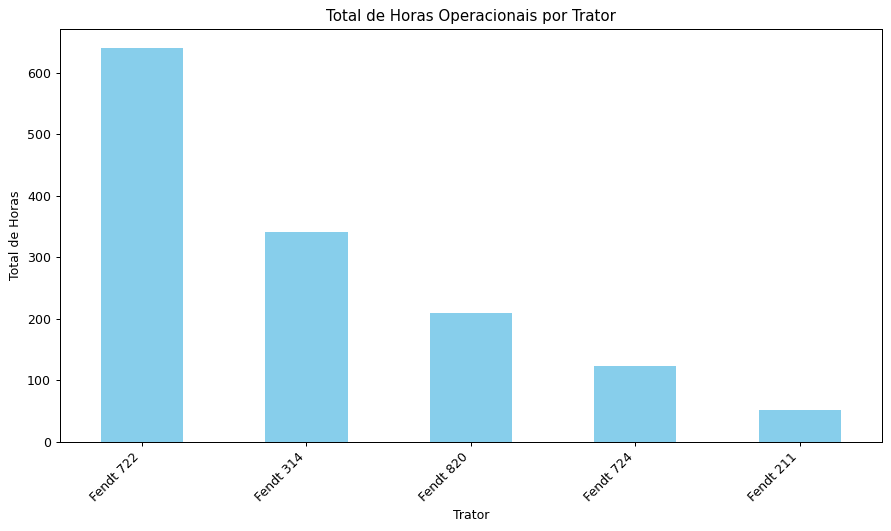

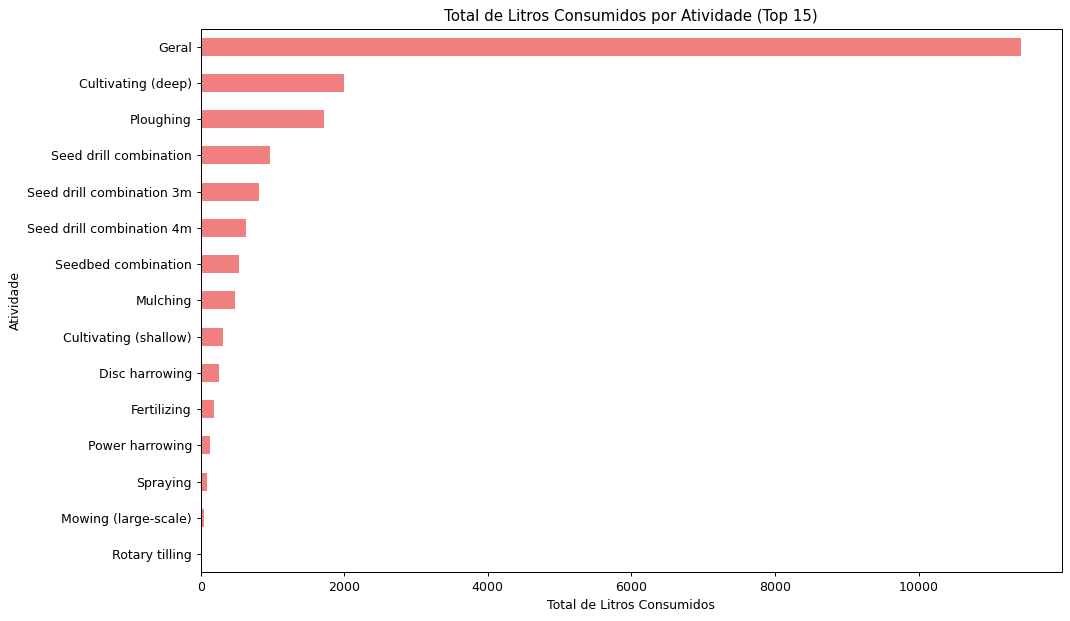

C:\Users\danie\AppData\Local\Temp\ipykernel_22200\1480107726.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stats_for_boxplot_filtered, x='activity', y='avg_fuel_consumption_l_h', order=ordered_activities, palette="Set2")


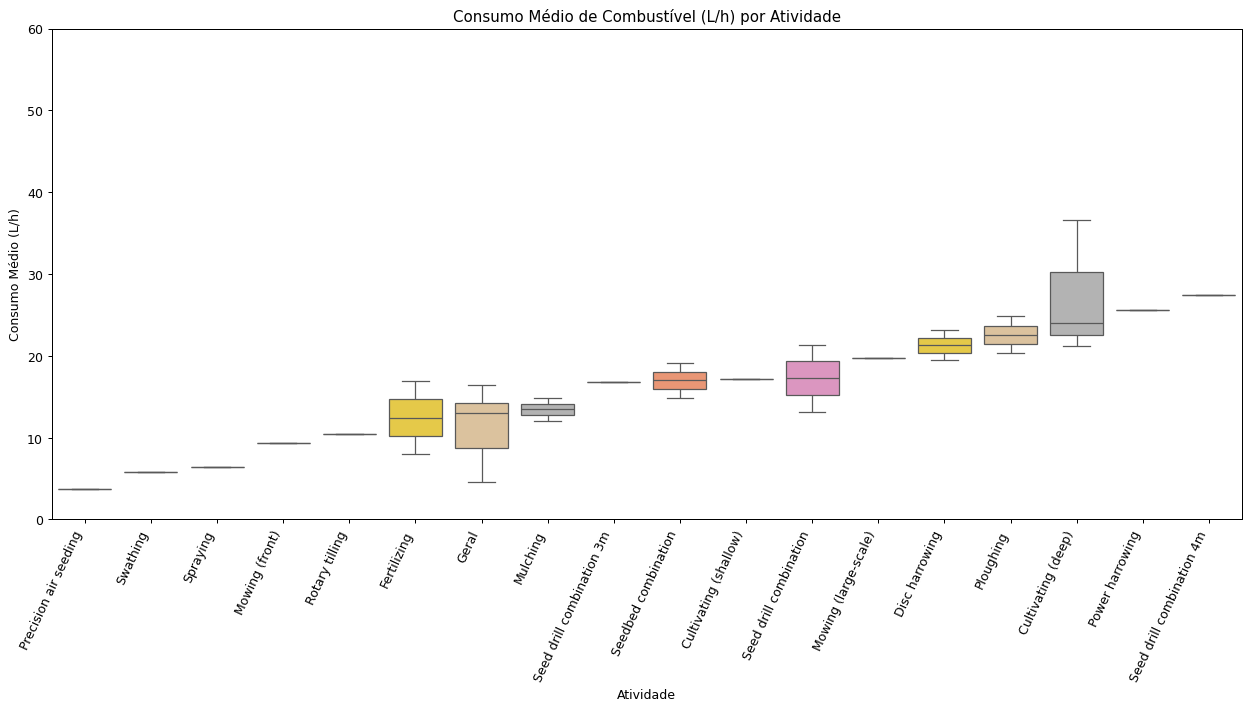

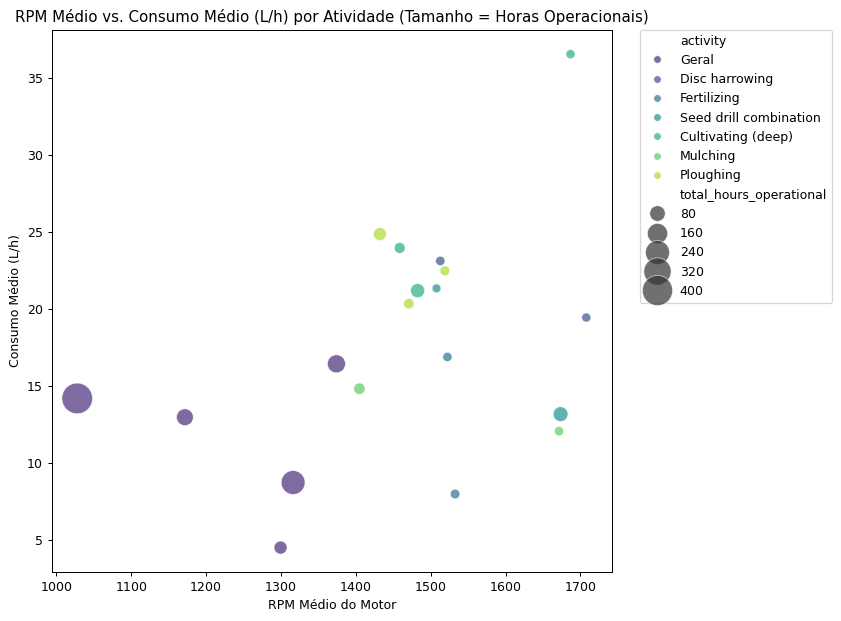


--- Célula 11 (Corrigida) concluída ---


In [16]:
# Célula 11 Corrigida: Análise de Sanidade e Visualizações Iniciais

# Certifique-se de que a Célula 10 foi executada e stats_df está disponível (ou carregue-o).
# curated_data_dir         # Definido na Célula 9
# import pandas as pd      # Da Célula 1

# --- Adicionar estas importações ---
import matplotlib.pyplot as plt
import seaborn as sns
# ------------------------------------

print("--- Iniciando Célula 11 (Corrigida): Análise de Sanidade e Visualizações ---")

# Configurações de plotagem (opcional)
# plt.style.use('seaborn-v0_8-whitegrid') # Exemplo de estilo
plt.rcParams['figure.figsize'] = (12, 6) # Exemplo de tamanho de figura
plt.rcParams['figure.dpi'] = 90 # Aumenta a resolução das figuras no notebook

stats_file_path = curated_data_dir / "telemetry_stats.parquet" # Ou telemetry_stats_v2.parquet se você usou esse nome
if not stats_file_path.exists():
    # Tenta o nome alternativo se o primeiro não for encontrado
    stats_file_path_v2 = curated_data_dir / "telemetry_stats_v2.parquet"
    if stats_file_path_v2.exists():
        stats_file_path = stats_file_path_v2
    else:
        print(f"ERRO: Arquivo de estatísticas não encontrado (tentou telemetry_stats.parquet e telemetry_stats_v2.parquet) em: {curated_data_dir}")
        print("Execute a Célula 10 primeiro.")
        # Para evitar mais erros, criamos um stats_df vazio se o arquivo não for encontrado
        stats_df = pd.DataFrame() 

if stats_file_path.exists(): # Procede apenas se o arquivo foi encontrado
    print(f"Carregando estatísticas de: {stats_file_path}")
    stats_df = pd.read_parquet(stats_file_path)

    print("\nVerificando dados nulos em stats_df:")
    print(stats_df.isnull().sum())

    print("\nEstatísticas descritivas básicas de stats_df:")
    # Seleciona apenas colunas numéricas para describe, e transpõe para melhor leitura
    numeric_cols_for_describe = ['total_hours_operational', 'total_liters_consumed', 
                                 'avg_engine_rpm', 'avg_veh_speed_m_s', 'avg_fuel_consumption_l_h']
    # Garante que apenas colunas existentes sejam usadas no describe
    existing_numeric_cols = [col for col in numeric_cols_for_describe if col in stats_df.columns]
    if existing_numeric_cols:
        print(stats_df[existing_numeric_cols].describe().T)
    else:
        print("Nenhuma das colunas numéricas esperadas para descrição foi encontrada em stats_df.")

    # --- Visualizações ---

    # 1. Total de Horas Operacionais por Trator
    if 'tractor' in stats_df.columns and 'total_hours_operational' in stats_df.columns:
        plt.figure(figsize=(10, 6))
        tractor_hours = stats_df.groupby('tractor')['total_hours_operational'].sum().sort_values(ascending=False)
        if not tractor_hours.empty:
            tractor_hours.plot(kind='bar', color='skyblue')
            plt.title('Total de Horas Operacionais por Trator')
            plt.ylabel('Total de Horas')
            plt.xlabel('Trator')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()
        else:
            print("Não há dados para o gráfico de horas por trator.")
            
    else:
        print("Colunas 'tractor' ou 'total_hours_operational' não encontradas para o gráfico de horas por trator.")

    # 2. Total de Litros Consumidos por Atividade
    if 'activity' in stats_df.columns and 'total_liters_consumed' in stats_df.columns:
        plt.figure(figsize=(12, 7))
        activity_fuel = stats_df.groupby('activity')['total_liters_consumed'].sum().sort_values(ascending=False).nlargest(15) # Top 15 atividades
        if not activity_fuel.empty:
            activity_fuel.plot(kind='barh', color='lightcoral')
            plt.title('Total de Litros Consumidos por Atividade (Top 15)')
            plt.xlabel('Total de Litros Consumidos')
            plt.ylabel('Atividade')
            plt.gca().invert_yaxis() # Atividade com maior consumo no topo
            plt.tight_layout()
            plt.show()
        else:
            print("Não há dados para o gráfico de consumo por atividade.")
    else:
        print("Colunas 'activity' ou 'total_liters_consumed' não encontradas para o gráfico de consumo por atividade.")

    # 3. Consumo Médio (L/h) por Atividade (Boxplot)
    if 'activity' in stats_df.columns and 'avg_fuel_consumption_l_h' in stats_df.columns:
        stats_for_boxplot = stats_df[stats_df['total_hours_operational'] > 0.1].copy() # Considera atividades com pelo menos ~6min

        activity_counts = stats_for_boxplot['activity'].value_counts()
        # Considera atividades que aparecem para pelo menos 1 trator (ou mais, se quiser menos atividades no boxplot)
        common_activities = activity_counts[activity_counts >= 1].index 
        
        if not common_activities.empty:
            stats_for_boxplot_filtered = stats_for_boxplot[stats_for_boxplot['activity'].isin(common_activities)]
            
            if not stats_for_boxplot_filtered.empty:
                plt.figure(figsize=(14, 8))
                ordered_activities = stats_for_boxplot_filtered.groupby('activity')['avg_fuel_consumption_l_h'].median().sort_values().index
                sns.boxplot(data=stats_for_boxplot_filtered, x='activity', y='avg_fuel_consumption_l_h', order=ordered_activities, palette="Set2")
                plt.title('Consumo Médio de Combustível (L/h) por Atividade')
                plt.ylabel('Consumo Médio (L/h)')
                plt.xlabel('Atividade')
                plt.xticks(rotation=65, ha='right') # Ajustado para melhor visualização dos rótulos
                # Ajusta limite y dinamicamente, mas com um mínimo para não achatar muito se os valores forem baixos
                min_y_limit = 0
                max_y_val = stats_for_boxplot_filtered['avg_fuel_consumption_l_h'].quantile(0.99) # Exclui outliers extremos do limite
                max_y_limit = max(60, max_y_val * 1.1) if pd.notnull(max_y_val) else 60
                plt.ylim(min_y_limit, max_y_limit) 
                plt.tight_layout()
                plt.show()
            else:
                print("Não há dados suficientes para o boxplot de consumo por atividade após filtragem.")
        else:
            print("Não há atividades comuns suficientes para o boxplot de consumo.")
            
    else:
        print("Colunas 'activity' ou 'avg_fuel_consumption_l_h' não encontradas para o boxplot.")

    # 4. Relação entre RPM Médio e Consumo Médio (L/h) por Atividade
    if all(col in stats_df.columns for col in ['avg_engine_rpm', 'avg_fuel_consumption_l_h', 'activity', 'total_hours_operational']):
        plt.figure(figsize=(12, 7))
        # Ponderar o tamanho dos pontos pelo total de horas para dar mais peso a observações mais longas
        # Filtra para evitar tamanhos zero ou negativos se houver horas problemáticas
        scatter_data_full = stats_df[stats_df['total_hours_operational'] > 0.1].copy()
        
        # Seleciona um subconjunto de atividades para não poluir o gráfico, se houver muitas
        top_activities_for_scatter = scatter_data_full['activity'].value_counts().nlargest(7).index
        scatter_data = scatter_data_full[scatter_data_full['activity'].isin(top_activities_for_scatter)]

        if not scatter_data.empty:
            sizes = scatter_data['total_hours_operational'] * 20 # Ajuste o multiplicador para o tamanho do ponto
            
            sns.scatterplot(data=scatter_data, 
                            x='avg_engine_rpm', 
                            y='avg_fuel_consumption_l_h', 
                            hue='activity', 
                            size='total_hours_operational',
                            sizes=(50, 600), # Define o range de tamanhos dos pontos
                            alpha=0.7,
                            palette="viridis")
            plt.title('RPM Médio vs. Consumo Médio (L/h) por Atividade (Tamanho = Horas Operacionais)')
            plt.xlabel('RPM Médio do Motor')
            plt.ylabel('Consumo Médio (L/h)')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
            plt.tight_layout(rect=[0, 0, 0.80, 1]) # Ajusta layout para a legenda caber
            plt.show()
        else:
            print("Não há dados suficientes para o scatter plot de RPM vs Consumo por atividade após filtragem.")
    else:
        print("Colunas necessárias para o scatter plot de RPM vs Consumo não encontradas.")
else:
    print("DataFrame stats_df não foi carregado ou está vazio. Gráficos não podem ser gerados.")

print("\n--- Célula 11 (Corrigida) concluída ---")
